# 4.1. Identify the Spatial Distribution of Educational Services

This notebook presents a basic clustering application that uses K-Means and DBSCAN to characterize the spatial distribution of educational institutions in Porto, Portugal.

<a href="https://colab.research.google.com/github/les2feup/geo-clustering/blob/main/01_Educational_Hubs.ipynb" target="_blank">
  <img src="https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=for-the-badge&logo=googlecolab&logoColor=white" alt="Open In Colab"/>
</a>

**Data Extraction with OSMnx**

To extract data on educational services in Porto, Portugal, we will use the OSMnx library, which allows us to download geospatial data from OpenStreetMap.

In [1]:
from pathlib import Path

import geopandas as gpd
import osmnx as ox

place = "Porto, Portugal"
tags = {"amenity": ["school"]}
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)
input_file = data_dir / "01_porto_schools.gpkg"

if input_file.exists():
    gdf_pois = gpd.read_file(input_file)
    print(f"Loaded input data from {input_file}")
else:
    gdf_pois = ox.features_from_place(place, tags)
    gdf_pois.to_file(input_file, driver="GPKG")
    print(f"Saved input data to {input_file}")

gdf_pois.head()

Matplotlib is building the font cache; this may take a moment.


Saved input data to data/01_porto_schools.gpkg


geometry addr:city addr:country  \
element id                                                             
node    2323725773  POINT (-8.60621 41.14811)     Porto           PT   
        2829209599  POINT (-8.60353 41.15188)       NaN          NaN   
        2925155478  POINT (-8.60727 41.15185)       NaN          NaN   
        3891282101  POINT (-8.60599 41.14888)     Porto           PT   
        4257803087  POINT (-8.64127 41.15694)       NaN          NaN   

                   addr:housenumber addr:postcode             addr:street  \
element id                                                                  
node    2323725773              220      4000-442   Rua de Santa Catarina   
        2829209599              NaN           NaN                     NaN   
        2925155478              NaN           NaN                     NaN   
        3891282101              310      4000-443   Rua de Santa Catarina   
        4257803087              318           NaN  Rua de António Cardoso   

                               alt_name amenity  \
element id                                        
node    2323725773  Externato Dom Dinis  school   
        2829209599                  NaN  school   
        2925155478                  NaN  school   
        3891282101                  NaN  school   
        4257803087                  NaN  school   

                                      contact:email  \
element id                                            
node    2323725773  anaraquelcunha@colegioddinis.pt   
        2829209599                              NaN   
        2925155478                              NaN   
        3891282101                              NaN   
        4257803087                              NaN   

                                       contact:phone  ... contact:mobile  \
element id                                            ...                  
node    2323725773                  +351 225 375 527  ...            NaN   
        2829209599                               NaN  ...            NaN   
        2925155478                               NaN  ...            NaN   
        3891282101  +351 222 081783; +351 934 561764  ...            NaN   
        4257803087                               NaN  ...            NaN   

                   roof:orientation nohousenumber inscription check_date  \
element id                                                                 
node    2323725773              NaN           NaN         NaN        NaN   
        2829209599              NaN           NaN         NaN        NaN   
        2925155478              NaN           NaN         NaN        NaN   
        3891282101              NaN           NaN         NaN        NaN   
        4257803087              NaN           NaN         NaN        NaN   

                   social_facility:for polling_station polling_station:ref  \
element id                                                                   
node    2323725773                 NaN             NaN                 NaN   
        2829209599                 NaN             NaN                 NaN   
        2925155478                 NaN             NaN                 NaN   
        3891282101                 NaN             NaN                 NaN   
        4257803087                 NaN             NaN                 NaN   

                   polling_station:zone type  
element id                                    
node    2323725773                  NaN  NaN  
        2829209599                  NaN  NaN  
        2925155478                  NaN  NaN  
        3891282101                  NaN  NaN  
        4257803087                  NaN  NaN  

[5 rows x 75 columns]

**Pre-processing the Data**

Convert the extracted geometries into points or centroids for clustering analysis.

In [2]:
import numpy as np

# Reproject to metric CRS (EPSG:3763 - Portuguese TM06/ETRS89)
gdf_pois = gdf_pois.to_crs(epsg=3763)

# Convert to points (centroids for non-point geometries)
gdf_pois["geometry"] = gdf_pois.geometry.apply(
    lambda geom: geom if geom.geom_type == "Point" else geom.centroid
)

# Extract coordinates (x, y) for clustering
coords = np.column_stack([gdf_pois.geometry.x, gdf_pois.geometry.y])

print(f"Preprocessed {len(coords)} POIs")

coords[:5]  # Display first 5 coordinate pairs

Preprocessed 169 POIs


array([[-39715.56207577, 164434.77501392],
       [-39488.45795856, 164851.96524223],
       [-39802.18522104, 164850.23529922],
       [-39696.16067314, 164519.91971672],
       [-42652.51024392, 165431.52707033]])

## K-Means Clustering

**Objective**: Divide the city into zones that group schools homogeneously.

**Application**:
- Choose optimal K using elbow method or silhouette score
- Apply K-means to schools coordinates
- Each cluster represents a "coverage region" useful for urban planning

**What it reveals**:
- Which zones have more schools
- If there's imbalance between regions (e.g., one cluster with 20 schools and another with 5)
- Spatial distribution patterns

**Visualization**:
- Map with colored clusters

**Finding the optimal number of clusters (K) using the elbow method**

In [3]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coords)
    inertias.append(kmeans.inertia_)

Plotting the elbow curve to visualize the elbow point.

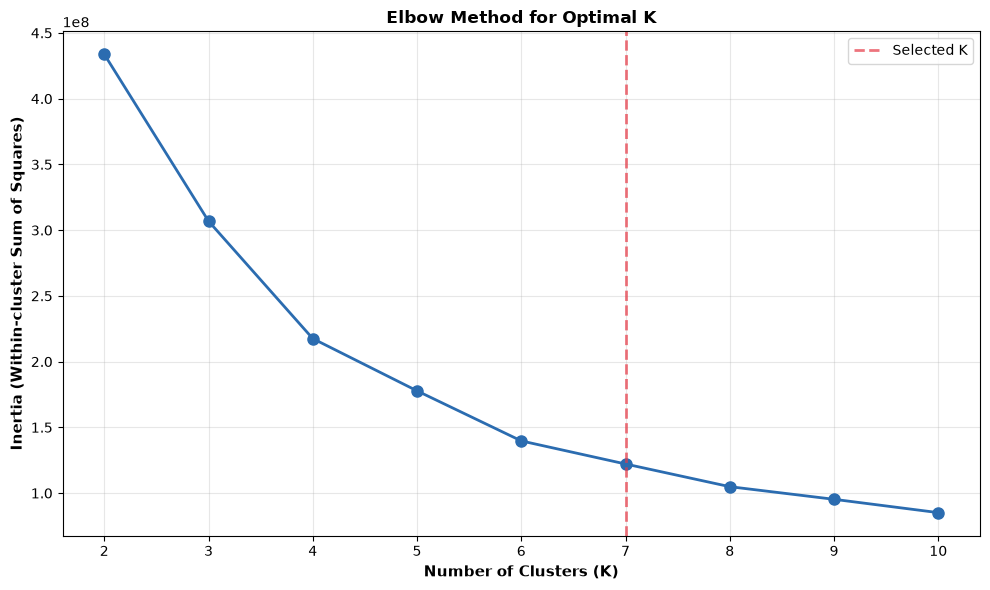

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(K_range, inertias, "-o", color="#2b6cb0", linewidth=2, markersize=8)
ax.set_xlabel("Number of Clusters (K)", fontsize=11, fontweight="bold")
ax.set_ylabel("Inertia (Within-cluster Sum of Squares)", fontsize=11, fontweight="bold")
ax.set_title('Elbow Method for Optimal K', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(K_range)

# Add marker at the selected K
ax.axvline(
    x=7, color="#E63946", linestyle="--", linewidth=2, alpha=0.7, label="Selected K"
)
ax.legend(fontsize=10)

plt.tight_layout()
fig.savefig(figures_dir / "01_kmeans_elbow_plot.png", dpi=300, bbox_inches="tight")
plt.show()

**Applying K-Means with the optimal K**

In [5]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(coords)

# Add cluster labels to GeoDataFrame
gdf_pois["kmeans_cluster"] = kmeans_labels

# Get cluster centers
cluster_centers = kmeans.cluster_centers_

Create summary statistics for each cluster to understand their characteristics.

In [7]:
import pandas as pd

cluster_summary = []

for cluster_id in range(7):
    cluster_data = gdf_pois[gdf_pois["kmeans_cluster"] == cluster_id]

    # Count by amenity
    schools = (cluster_data["amenity"] == "school").sum()
    total = len(cluster_data)

    cluster_summary.append(
        {
            "Cluster": cluster_id,
            "Schools": schools,
        }
    )

summary_df = pd.DataFrame(cluster_summary)
print(summary_df.to_string(index=False))

 Cluster  Schools
       0       19
       1       21
       2       30
       3       26
       4       16
       5       38
       6       19


Visualize K-means clusters on a map

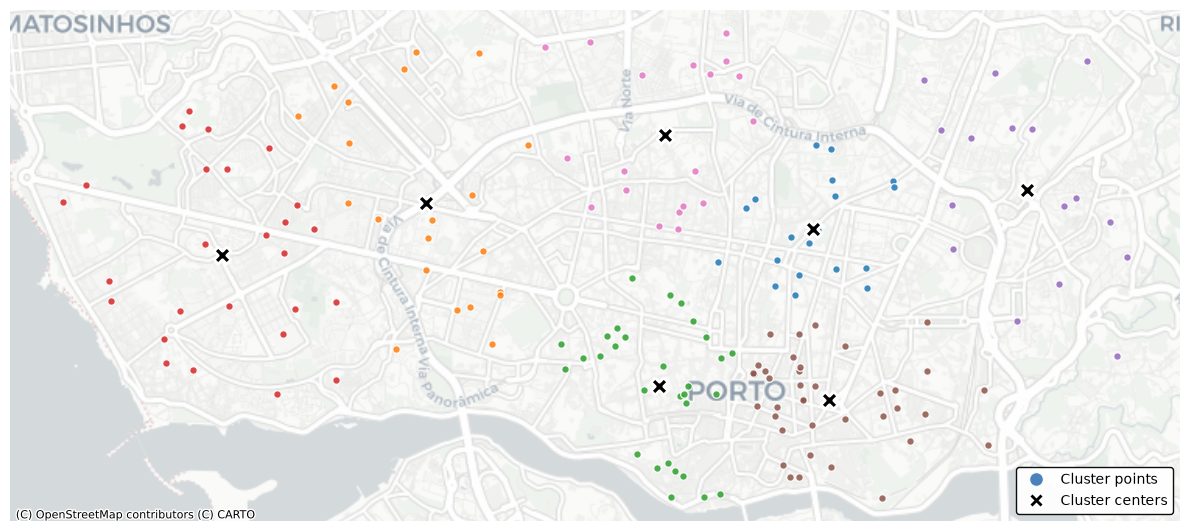

In [8]:
import contextily as cx
import geopandas as gpd
from shapely.geometry import Point
from matplotlib.lines import Line2D


# Create figure
fig, ax = plt.subplots(figsize=(12, 12))

# Convert to Web Mercator for basemap
gdf_pois_webm = gdf_pois.to_crs(epsg=3857)
coords_webm = np.column_stack([gdf_pois_webm.geometry.x, gdf_pois_webm.geometry.y])

# Use a colormap for clusters
cmap = plt.get_cmap("tab10")

# Plot each cluster separately
for cluster_id in range(7):
    cluster_mask = kmeans_labels == cluster_id
    cluster_coords = coords_webm[cluster_mask]

    ax.scatter(
        cluster_coords[:, 0],
        cluster_coords[:, 1],
        c=[cmap(cluster_id)],
        s=30,
        marker="o",
        edgecolors="white",
        linewidths=1,
        alpha=0.85,
        zorder=25,
    )

# Convert cluster centers to GeoDataFrame in Web Mercator (EPSG:3857) for plotting
centers_gdf = gpd.GeoDataFrame(
    geometry=[Point(c[0], c[1]) for c in kmeans.cluster_centers_], crs="EPSG:3763"
).to_crs(epsg=3857)

# Plot cluster centers as large X markers
for idx, center in enumerate(centers_gdf.geometry):
    ax.scatter(
        center.x,
        center.y,
        c="black",
        s=150,
        marker="X",
        edgecolors="white",
        linewidths=2,
        alpha=1.0,
        zorder=30,
    )

# Set equal aspect ratio to prevent stretching
ax.set_aspect("equal", adjustable="box")

# Add basemap AFTER setting limits
cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.CartoDB.Positron)

# Create custom legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#2b6cb0",
        markersize=10,
        markeredgecolor="white",
        markeredgewidth=1,
        label="Cluster points",
        linestyle="None",
        alpha=0.85,
    ),
    Line2D(
        [0],
        [0],
        marker="X",
        color="black",
        markersize=12,
        markeredgecolor="white",
        markeredgewidth=2,
        label="Cluster centers",
        linestyle="None",
    ),
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    fancybox=True,
    fontsize=10,
    framealpha=0.95,
    edgecolor="black",
    facecolor="white",
)

ax.set_axis_off()
plt.tight_layout()
fig.savefig(figures_dir / "01_kmeans_cluster_map.png", dpi=300, bbox_inches="tight")
plt.show()

## DBSCAN Clustering

**Objective**: Identify local concentrations of schools — high-density zones.

**Application**:
- Adjust `eps` using k-NN distance plot
- Choose `min_samples` based on expected density
- DBSCAN groups nearby schools and ignores dispersed zones

**What it reveals**:
- "Educational hubs" with many schools in a small radius
- Areas with overlap of schools (e.g., urban centers)
- Zones without clusters → potential underserved areas

**Visualization**:
- Map with DBSCAN clusters
- Noise points (label -1) highlighted as isolated zones

**Pre-prossessing**

In [9]:
# Keep geographic CRS (EPSG:4326 - WGS84 lat/lon for haversine metric)
gdf_pois = gdf_pois.to_crs(epsg=4326)

# Convert to points (centroids for non-point geometries)
gdf_pois["geometry"] = gdf_pois.geometry.apply(
    lambda geom: geom if geom.geom_type == "Point" else geom.centroid
)

# Extract coordinates (lon, lat) for clustering
coords = np.radians(np.column_stack([gdf_pois.geometry.y, gdf_pois.geometry.x]))

print(f"Preprocessed {len(coords)} POIs")

coords[:5]  # Display first 5 coordinate pairs

Preprocessed 169 POIs


array([[ 0.71817007, -0.15020675],
       [ 0.71823583, -0.15016   ],
       [ 0.71823529, -0.15022523],
       [ 0.71818347, -0.15020281],
       [ 0.71832411, -0.15081856]])

**Identify the optimal `eps` using k-NN distance plot**

In [10]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5  # Use k = min_samples
nbrs = NearestNeighbors(n_neighbors=min_samples, metric="haversine").fit(coords)
distances, indices = nbrs.kneighbors(coords)

Plot the k-NN distance graph to find the elbow point indicating optimal `eps`.

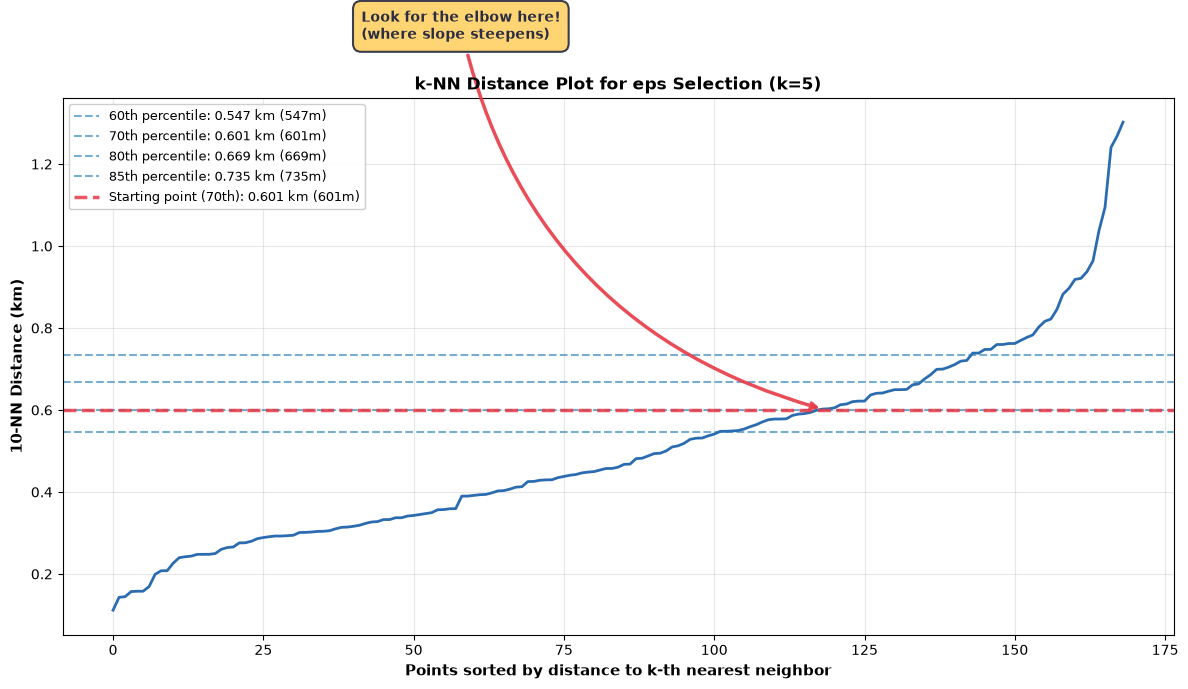


k-NN Distance Statistics (k=10):
  • Min distance: 0.1117 km (111.7m)
  • Mean distance: 0.5021 km (502.1m)
  • Median distance: 0.4605 km (460.5m)
  • Max distance: 1.3022 km (1302.2m)

Suggested eps values:
  • 60th percentile: 0.5466 km (547m)
  • 70th percentile: 0.6010 km (601m)
  • 80th percentile: 0.6686 km (669m)
  • 85th percentile: 0.7352 km (735m)

Starting point: 0.6010 km (601m)
   Then adjust based on results:
   - Too many noise points → increase eps slightly
   - Giant cluster → decrease eps significantly
   - Good balance → you found the sweet spot!


In [11]:
# Convert distances from radians to kilometers
distances_km = distances[:, min_samples - 1] * 6371.0

# Sort distances in ascending order
distances_sorted = np.sort(distances_km)

# Plot k-NN distance graph
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(distances_sorted, linewidth=2, color="#2b6cb0")
ax.set_xlabel(
    "Points sorted by distance to k-th nearest neighbor", fontsize=11, fontweight="bold"
)
ax.set_ylabel(f"{k}-NN Distance (km)", fontsize=11, fontweight="bold")
ax.set_title(
    f"k-NN Distance Plot for eps Selection (k={min_samples})",
    fontsize=12,
    fontweight="bold",
)
ax.grid(True, alpha=0.3)

# Suggest eps values at different percentiles
# The elbow is typically between 60-85th percentile
percentiles = [60, 70, 80, 85]
suggested_eps = []

for p in percentiles:
    eps_val = np.percentile(distances_sorted, p)
    suggested_eps.append(eps_val)
    ax.axhline(
        y=eps_val,
        linestyle="--",
        linewidth=1.5,
        alpha=0.6,
        label=f"{p}th percentile: {eps_val:.3f} km ({eps_val*1000:.0f}m)",
    )

# Highlight a recommended eps 
recommended_eps = suggested_eps[1]  
ax.axhline(
    y=recommended_eps,
    color="#E63946",
    linestyle="--",
    linewidth=2.5,
    alpha=0.85,
    label=f"Starting point (70th): {recommended_eps:.3f} km ({recommended_eps*1000:.0f}m)",
)

ax.legend(fontsize=9, loc="upper left", framealpha=0.95)

# Add annotation pointing to the elbow
elbow_idx = int(len(distances_sorted) * 0.70)  
elbow_dist = distances_sorted[elbow_idx]
ax.annotate(
    "Look for the elbow here!\n(where slope steepens)",
    xy=(elbow_idx, elbow_dist),
    xytext=(elbow_idx * 0.35, elbow_dist * 2.5),
    arrowprops=dict(
        arrowstyle="->",
        color="#E63946",
        lw=2.5,
        alpha=0.9,
        connectionstyle="arc3,rad=0.3",
    ),
    fontsize=10,
    fontweight="bold",
    color="#2B2D42",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#FFD166",
        edgecolor="#2B2D42",
        linewidth=1.5,
        alpha=0.92,
    ),
)

plt.tight_layout()
fig.savefig(figures_dir / "01_knn_distance_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nk-NN Distance Statistics (k={k}):")
print("=" * 60)
print(
    f"  • Min distance: {distances_sorted.min():.4f} km ({distances_sorted.min()*1000:.1f}m)"
)
print(
    f"  • Mean distance: {distances_sorted.mean():.4f} km ({distances_sorted.mean()*1000:.1f}m)"
)
print(
    f"  • Median distance: {np.median(distances_sorted):.4f} km ({np.median(distances_sorted)*1000:.1f}m)"
)
print(
    f"  • Max distance: {distances_sorted.max():.4f} km ({distances_sorted.max()*1000:.1f}m)"
)
print("\nSuggested eps values:")
for p, eps_val in zip(percentiles, suggested_eps):
    print(f"  • {p}th percentile: {eps_val:.4f} km ({eps_val*1000:.0f}m)")
print(f"\nStarting point: {recommended_eps:.4f} km ({recommended_eps*1000:.0f}m)")
print("   Then adjust based on results:")
print("   - Too many noise points → increase eps slightly")
print("   - Giant cluster → decrease eps significantly")
print("   - Good balance → you found the sweet spot!")
print("=" * 60)

**Apply DBSCAN with selected parameters**

In [12]:
from sklearn.cluster import DBSCAN

eps_km = 0.550  # 550 meters = 0.550 kilometers

# IMPORTANT: For haversine metric, eps must be in RADIANS
# Convert km to radians by dividing by Earth's radius (6371 km)
eps_radians = eps_km / 6371.0

dbscan = DBSCAN(eps=eps_radians, min_samples=min_samples, metric="haversine")
dbscan_labels = dbscan.fit_predict(coords)

# Add labels to GeoDataFrame
gdf_pois["dbscan_cluster"] = dbscan_labels

output_file = data_dir / "01_educational_hubs_clusters.gpkg"
gdf_pois.to_file(output_file, driver="GPKG")
print(f"Saved clustered data to {output_file}")

In [13]:
# Count clusters and noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN Clustering Results")
print("=" * 60)
print(f"  eps: {eps_km*1000:.0f}m")
print(f"  min_samples: {min_samples}")
print("   metric: haversine")
print(f"  Number of clusters: {n_clusters}")
print(f"  Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(
    f"  Number of clustered points: {len(dbscan_labels) - n_noise} ({(len(dbscan_labels) - n_noise)/len(dbscan_labels)*100:.1f}%)"
)

# Create summary table
cluster_summary = []

for cluster_id in sorted(set(dbscan_labels)):
    if cluster_id == -1:
        continue

    cluster_data = gdf_pois[gdf_pois["dbscan_cluster"] == cluster_id]
    schools = len(cluster_data)

    cluster_summary.append(
        {
            "Cluster": cluster_id,
            "Schools": schools,
        }
    )

# Add noise as a separate row
cluster_summary.append(
    {
        "Cluster": "Noise",
        "Schools": n_noise,
    }
)

summary_df = pd.DataFrame(cluster_summary)
print("\nCluster Summary:")
print(summary_df.to_string(index=False))
print("=" * 60)


DBSCAN Clustering Results
  eps: 550m
  min_samples: 5
   metric: haversine
  Number of clusters: 6
  Number of noise points: 42 (24.9%)
  Number of clustered points: 127 (75.1%)

Cluster Summary:
Cluster  Schools
      0       84
      1       11
      2       12
      3        8
      4        5
      5        7
  Noise       42


**Visualize DBSCAN clusters on a map**

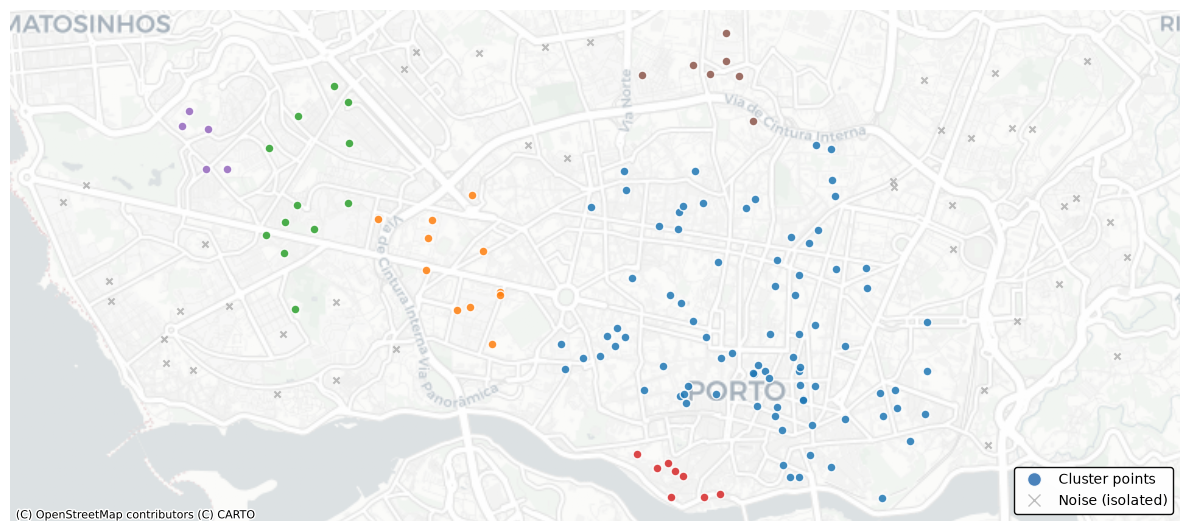

In [14]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 12))

# Convert to Web Mercator for basemap
gdf_pois_webm = gdf_pois.to_crs(epsg=3857)
coords_webm = np.column_stack([gdf_pois_webm.geometry.x, gdf_pois_webm.geometry.y])

# Use colormap for clusters
cmap = plt.get_cmap("tab10")

# Plot clusters
unique_labels = set(dbscan_labels)
for cluster_id in unique_labels:
    if cluster_id == -1:
        # Noise points in gray
        cluster_mask = dbscan_labels == cluster_id
        cluster_coords = coords_webm[cluster_mask]
        ax.scatter(
            cluster_coords[:, 0],
            cluster_coords[:, 1],
            c="gray",
            s=20,
            marker="x",
            alpha=0.5,
            zorder=20,
            label="Noise",
        )
    else:
        # Cluster points
        cluster_mask = dbscan_labels == cluster_id
        cluster_coords = coords_webm[cluster_mask]
        ax.scatter(
            cluster_coords[:, 0],
            cluster_coords[:, 1],
            c=[cmap(cluster_id)],
            s=40,
            marker="o",
            edgecolors="white",
            linewidths=1,
            alpha=0.85,
            zorder=25,
        )

# Set axis limits with padding
x_min, x_max = coords_webm[:, 0].min(), coords_webm[:, 0].max()
y_min, y_max = coords_webm[:, 1].min(), coords_webm[:, 1].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05
ax.set_xlim(x_min - x_margin, x_max + x_margin)
ax.set_ylim(y_min - y_margin, y_max + y_margin)

# Set equal aspect ratio
ax.set_aspect("equal", adjustable="box")

# Add basemap
cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.CartoDB.Positron, alpha=0.8)

# Create custom legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#2b6cb0",
        markersize=10,
        markeredgecolor="white",
        markeredgewidth=1,
        label="Cluster points",
        linestyle="None",
        alpha=0.85,
    ),
    Line2D(
        [0],
        [0],
        marker="x",
        color="gray",
        markersize=8,
        linestyle="None",
        alpha=0.5,
        label="Noise (isolated)",
    ),
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    fancybox=True,
    fontsize=10,
    framealpha=0.95,
    edgecolor="black",
    facecolor="white",
)

ax.set_axis_off()
plt.tight_layout()
fig.savefig(figures_dir / "01_dbscan_cluster_map.png", dpi=300, bbox_inches="tight")
plt.show()